# Copula Theory in Statistical Inference and Financial Applications

A copula is a mathematical object that separates marginal distributions from the dependence structure of a multivariate random vector. In statistical inference, it provides a coherent framework to construct joint distributions from univariate marginals and a multivariate dependence function.

#### Theoretical foundations
Given a random vector $X = (X_1, \ldots, X_d)$ with joint cumulative distribution function $F$ and marginal CDFs $F_i$, Sklar's theorem states that there exists a copula $C$ such that

$$ F(x_1, \ldots, x_d) = C\big(F_1(x_1), \ldots, F_d(x_d)\big). $$

When the marginals are continuous, the copula $C$ is unique. If densities exist, the joint density admits the decomposition

$$ f(x_1, \ldots, x_d) = c\big(F_1(x_1), \ldots, F_d(x_d)\big) \prod_{i=1}^d f_i(x_i), $$

where

$$ c(u_1, \ldots, u_d) = \frac{\partial^d}{\partial u_1 \cdots \partial u_d}C(u_1, \ldots, u_d). $$

This decomposition highlights two inferential components:
- Marginal inference: estimation of each $F_i$ or $f_i$.
- Dependence inference: estimation of the copula $C$ or its density $c$.

#### Inference methodology
Copula inference is typically organized in one of the following approaches:

- Parametric inference:
    - Specify parametric marginals $F_i(x_i; \theta_i)$ and a parametric copula $C(u_1, \ldots, u_d; \psi)$.
    - Estimate parameters by full maximum likelihood:

        $$ \hat{\theta}, \hat{\psi} = \arg\max_{\theta, \psi} \sum_{t=1}^n \log f(x_{t1}, \ldots, x_{td}; \theta, \psi). $$

- Inference Functions for Margins (IFM):
    - Step 1: estimate marginal parameters $\hat{\theta}_i$ independently.
    - Step 2: estimate copula parameter $\hat{\psi}$ using pseudo-observations $u_{ti} = F_i(x_{ti}; \hat{\theta}_i)$.

- Semiparametric inference:
    - Estimate marginals nonparametrically via empirical CDFs $\hat{F}_i$.
    - Estimate copula parameters from pseudo-observations

        $$ \hat{u}_{ti} = \hat{F}_i(x_{ti}). $$

Important properties:
- Invariance: copulas are invariant under strictly increasing transformations of marginals.
- Tail dependence: measures the likelihood of joint extreme events.

For a bivariate copula $C$, the tail dependence coefficients are

$$ \lambda_U = \lim_{u \to 1^-} \frac{1 - 2u + C(u,u)}{1-u}, $$
$$ \lambda_L = \lim_{u \to 0^+} \frac{C(u,u)}{u}. $$

These coefficients capture asymptotic dependence in the upper and lower tails.

#### Common copula families
- Gaussian copula:

    $$ C_\Sigma(u,v) = \Phi_\Sigma(\Phi^{-1}(u), \Phi^{-1}(v)), $$

    where $\Phi_\Sigma$ is the multivariate normal CDF and $\Phi^{-1}$ the inverse standard normal CDF. It yields symmetric dependence with zero tail dependence in the bivariate case.

- Student-$t$ copula:

    $$ C_{\nu,\Sigma}(u,v) = t_{\nu,\Sigma}(t_\nu^{-1}(u), t_\nu^{-1}(v)), $$

    with degrees of freedom $\nu$. It accommodates heavier tails and nonzero tail dependence.

- Archimedean copulas:

    $$ C(u_1, \ldots, u_d) = \varphi^{-1}\big(\varphi(u_1) + \cdots + \varphi(u_d)\big), $$

    where $\varphi$ is a decreasing generator. Examples include Clayton, Gumbel, and Frank; these models capture asymmetric dependence and particular tail behaviors.

#### Financial applications
In finance, copulas separate marginal risk characteristics from joint dependence, making them suitable for:

- Credit risk: default probabilities of obligors are marginals, while joint default behavior is encoded by the copula.
- Portfolio risk: asset returns or losses have individual distributions, and the copula determines joint loss behavior.
- Structured products: valuation of CDO tranches depends on dependence among underlying credit events.

Example applications:
- Portfolio loss distribution:

    $$ L = \sum_{i=1}^d w_i \ell_i(X_i), $$

    where each loss component $\ell_i(X_i)$ has a marginal law and joint dependence given by a copula. The multivariate law is necessary to compute Value-at-Risk and Expected Shortfall.

- Default correlation modeling:
    - Use a latent variable representation with default thresholds as marginals and dependence encoded by a Gaussian or Student-$t$ copula.
    - The probability of $k$ defaults depends on the joint CDF of the latent factors.

#### Limitations and critical considerations
- Model risk: misspecified copulas can underestimate joint extremes.
- Calibration: inference requires sufficient data and robust estimation of marginals and dependence.
- Dynamic dependence: many copula models are static; financial dependence often evolves over time, motivating time-varying or regime-switching copulas.

This academic treatment emphasizes that copulas are fundamental tools for modeling multivariate distributions, allowing researchers to decouple marginals from dependence, estimate each component separately, quantify tail behavior, and apply these results to financial settings where joint extreme outcomes and credit dependence are central.


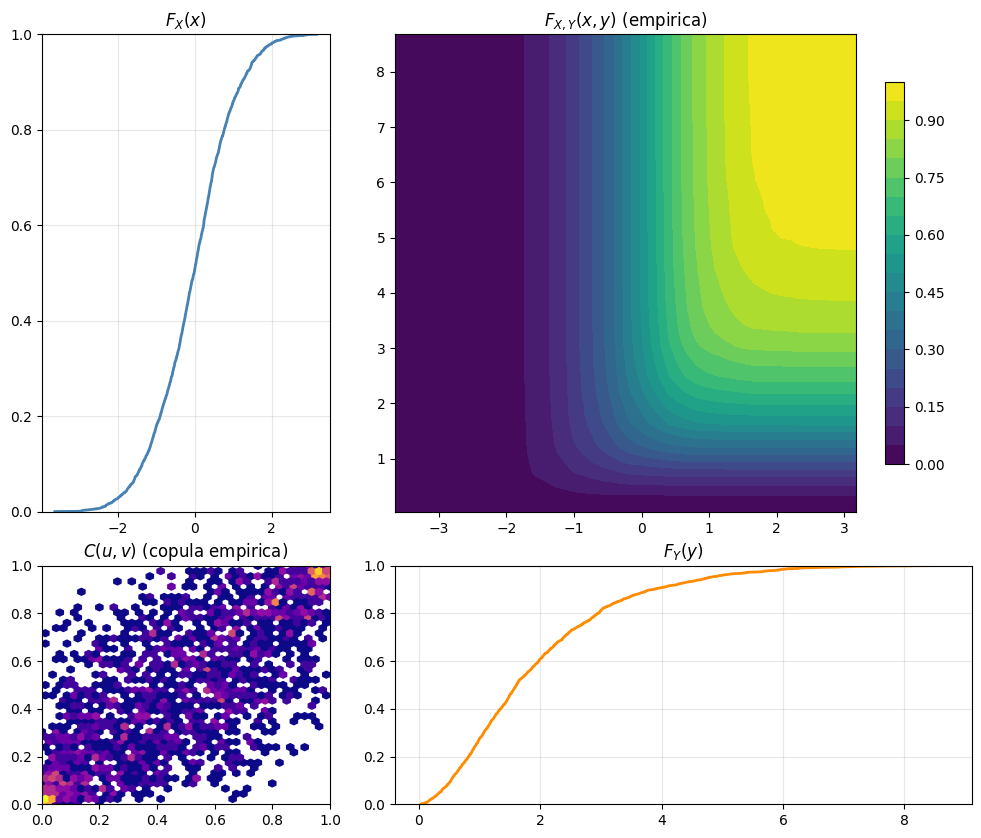

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.gridspec import GridSpec

# -----------------------
# DATI EMPIRICI RANDOM
# -----------------------
N = 2000

rng = np.random.default_rng(42)

# correlazione fissa (solo per generare dipendenza)
rho = 0.7

z1 = rng.standard_normal(N)
z2 = rho * z1 + np.sqrt(1 - rho**2) * rng.standard_normal(N)

# trasformazione copula → marginali NON gaussiane
u = stats.norm.cdf(z1)
v = stats.norm.cdf(z2)

x = stats.norm.ppf(u)          # marginale X normale
y = stats.gamma(a=2).ppf(v)    # marginale Y gamma

# -----------------------
# FIGURA
# -----------------------
fig = plt.figure(figsize=(12, 10))

gs = GridSpec(
    2, 2,
    width_ratios=[1, 2],
    height_ratios=[2, 1],
    wspace=0.15,
    hspace=0.15
)

ax_fx = fig.add_subplot(gs[0, 0])
ax_fxy = fig.add_subplot(gs[0, 1])
ax_cop = fig.add_subplot(gs[1, 0])
ax_fy = fig.add_subplot(gs[1, 1])

# =======================
# F_X(x)
# =======================
xs = np.sort(x)
Fx = np.arange(1, N + 1) / N

ax_fx.plot(xs, Fx, lw=2, color="steelblue")
ax_fx.set_title(r"$F_X(x)$")
ax_fx.set_ylim(0, 1)
ax_fx.grid(alpha=0.3)

# =======================
# F_Y(y)
# =======================
ys = np.sort(y)
Fy = np.arange(1, N + 1) / N

ax_fy.plot(ys, Fy, lw=2, color="darkorange")
ax_fy.set_title(r"$F_Y(y)$")
ax_fy.set_ylim(0, 1)
ax_fy.grid(alpha=0.3)

# =======================
# COPULA EMPIRICA C(u,v)
# =======================
ax_cop.hexbin(
    u, v,
    gridsize=40,
    cmap="plasma",
    mincnt=1
)

ax_cop.set_xlim(0, 1)
ax_cop.set_ylim(0, 1)
ax_cop.set_title(r"$C(u,v)$ (copula empirica)")

# =======================
# CDF CONGIUNTA F(x,y)
# =======================
xx = np.linspace(x.min(), x.max(), 50)
yy = np.linspace(y.min(), y.max(), 50)

Fxy = np.zeros((len(xx), len(yy)))

for i, xi in enumerate(xx):
    for j, yj in enumerate(yy):
        Fxy[i, j] = np.mean((x <= xi) & (y <= yj))

cont = ax_fxy.contourf(
    xx,
    yy,
    Fxy.T,
    levels=20,
    cmap="viridis"
)

ax_fxy.set_title(r"$F_{X,Y}(x,y)$ (empirica)")
fig.colorbar(cont, ax=ax_fxy, shrink=0.8)

plt.show()

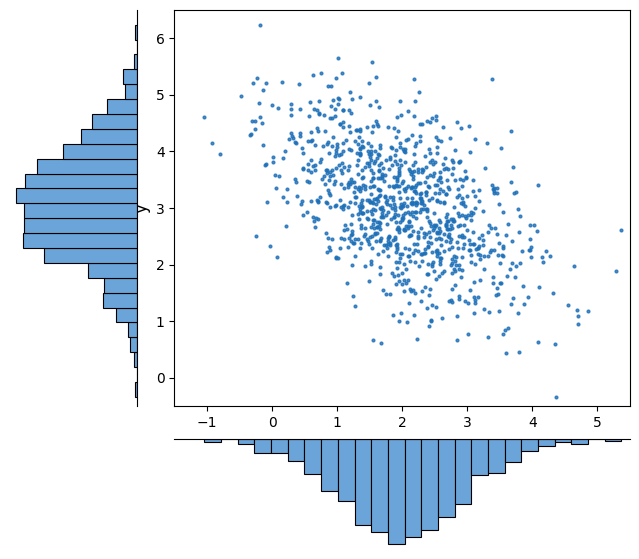

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Rigenerazione dei dati statistici
np.random.seed(42)
n_samples = 1000

mu_x, sigma_x = 2, 1
mu_y, sigma_y = 3, 1
rho = -0.55
covariance_matrix = [
    [sigma_x**2, rho * sigma_x * sigma_y],
    [rho * sigma_x * sigma_y, sigma_y**2]
]

data = np.random.multivariate_normal([mu_x, mu_y], covariance_matrix, size=n_samples)
x = data[:, 0]
y = data[:, 1]

# 2. NUOVA STRUTTURA DEL LAYOUT (Angolo vuoto in basso a sinistra)
fig = plt.figure(figsize=(8, 7))
grid = plt.GridSpec(4, 4, hspace=0.3, wspace=0.3)

# Scatter Plot: Spostato in Alto a Destra (righe 0:3, colonne 1:4)
ax_joint = fig.add_subplot(grid[0:3, 1:4])

# Istogramma X: Spostato in Basso a Destra (riga 3, colonne 1:4)
ax_marg_x = fig.add_subplot(grid[3, 1:4], sharex=ax_joint)

# Istogramma Y: Spostato in Alto a Sinistra (righe 0:3, colonna 0)
ax_marg_y = fig.add_subplot(grid[0:3, 0], sharey=ax_joint)

color_blue = '#6ba4d9'

# A. Grafico Centrale (Scatter)
ax_joint.scatter(x, y, s=4, color='#1d70b8', alpha=0.8)
ax_joint.set_xlabel('x', fontsize=12)
ax_joint.set_ylabel('y', fontsize=12)
ax_joint.set_xlim(-1.5, 5.5)
ax_joint.set_ylim(-0.5, 6.5)

# B. Marginale X (Sotto lo scatter)
ax_marg_x.hist(x, bins=25, color=color_blue, edgecolor='black', linewidth=0.8)
ax_marg_x.invert_yaxis() # Mantiene l'effetto a specchio verso il basso

# Pulizia asse X duplicato
ax_marg_x.spines['top'].set_visible(True) # Linea di giunzione con lo scatter
ax_marg_x.spines['bottom'].set_visible(False)
ax_marg_x.spines['left'].set_visible(False)
ax_marg_x.spines['right'].set_visible(False)
ax_marg_x.tick_params(axis='both', which='both', bottom=False, top=False, labelbottom=False, left=False, labelleft=False)

# C. Marginale Y (A sinistra dello scatter)
ax_marg_y.hist(y, bins=25, orientation='horizontal', color=color_blue, edgecolor='black', linewidth=0.8)
ax_marg_y.invert_xaxis() # Mantiene l'effetto a specchio verso sinistra

# Pulizia asse Y duplicato
ax_marg_y.spines['top'].set_visible(False)
ax_marg_y.spines['bottom'].set_visible(False)
ax_marg_y.spines['left'].set_visible(False)
ax_marg_y.spines['right'].set_visible(True) # Linea di giunzione con lo scatter
ax_marg_y.tick_params(axis='both', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

plt.show()